# Week 4 : Multi-Tool Assistant

## Purpose:
A model becomes an agent when it can call tools, read the results, and decide what to do next. This notebook builds that loop end to end, with schemas tight enough that the model cannot wander and has failure handling honest enough that a broken call becomes a recovery rather than a crash. One of your tools runs code, so you also meet the first real safety problem in agentic systems. (NEEDS EDITING)

### Learning Goals:
* Define tools with constrained JSON schemas using enums, required fields, and types.
* Implement the full function-calling loop: send tools, intercept the call, execute, return the result, let the model continue.
* Handle failure gracefully and turn a structured error into a self-correction.


### Explanation 
This notebook builds on the Week 3 HCAHPS classifier by turning it into a multi-tool assistant. HCAHPS, or the Hospital Consumer Assessment of Healthcare Providers and Systems, is a standardized patient survey that measures experiences with hospital care, such as communication, responsiveness, discharge preparation, and the hospital environment. HCAHPS results are publicly reported, and patient-experience measures contribute to Medicare reimbursement through the Hospital Value-Based Purchasing program. In this project, the model interprets the fuzzy meaning of a patient comment and assigns an HCAHPS category, while deterministic tools record and quantify those decisions. This separates subjective language interpretation (LLM) from reliable counting and reporting (Deterministic Tools).

**Tools:**
* `record_classification`: Validates an HCAHPS label and confidence level, then adds the classification to a running tally.
* `get_summary`: Returns deterministic counts and percentages for recorded HCAHPS categories.
* `plot_distribution`: Creates a bar chart showing the distribution of recorded classifications.


# Week 4: Multi-Tool Assistant

## Purpose

A language model becomes an agent when it can select tools, provide structured arguments, interpret their results, and decide what to do next. This notebook builds that process end to end by extending the Week 3 HCAHPS classifier into a multi-tool assistant.

The assistant combines language-model interpretation with deterministic Python tools. Constrained schemas limit the model's available actions, while validation and structured error responses allow invalid tool calls to become opportunities for recovery instead of causing the application to crash. A guarded statistics runner also introduces safety controls for model-requested calculations through an explicit allowlist, pre-execution validation, resource limits, and blocked operation categories.

## Learning Goals

- Define tools with constrained JSON schemas using explicit types, required fields, enums, and disallowed additional properties.
- Implement the complete function-calling loop: send tool definitions, intercept calls, validate arguments, execute functions, return results, and allow the model to continue.
- Separate subjective language interpretation from deterministic data recording, calculation, and visualization.
- Handle invalid arguments and execution failures through structured error responses.
- Restrict model-requested calculations with an allowlist, pre-execution checks, record and time limits, and named blocked operations.
- Evaluate a multi-step tool-ordering failure and determine whether tool descriptions and system instructions improve recovery.

## Explanation

HCAHPS, or the Hospital Consumer Assessment of Healthcare Providers and Systems, is a standardized survey that measures patients' experiences with hospital care. Its categories include communication with nurses and doctors, staff responsiveness, medication communication, discharge information, care transitions, and the hospital environment.

The model handles the ambiguous language task of interpreting a patient comment and selecting one primary HCAHPS category. Deterministic Python tools perform operations that should be reproducible, including recording classifications, calculating summaries, and creating charts.

Each tool has a constrained JSON schema. The dispatcher validates the model's arguments against that schema before calling the corresponding Python function. Successful results and structured errors are returned to the model with the matching call ID. The model can then call another tool, correct an invalid request, or produce its final answer.

The evaluation section sends requests that require individual and sequential tool calls. It also examines a failure in which the model calculates a ledger statistic before recording the new classification. Changes to the tool description and system prompt are evaluated as possible corrections to this ordering problem.

## Tools

- `record_classification`: Records one HCAHPS label, confidence level, and rationale in the classification ledger after validating the supplied arguments.
- `get_summary`: Returns deterministic counts and percentages grouped by HCAHPS label or confidence level.
- `plot_distribution`: Creates and saves a bar chart showing the distribution of recorded labels or confidence levels.
- `run_guarded_summary_statistic`: Runs one allowlisted, read-only ledger calculation, such as a total, most-common label, or percentage for a selected label or confidence level. It applies pre-execution validation, a 50-record limit, and a 250-millisecond elapsed-time budget while excluding arbitrary code, filesystem, network, import, and process access.

## Imports

In [1]:
import os, json
from dotenv import load_dotenv
from pathlib import Path
from azure.ai.projects import AIProjectClient
from azure.identity import DefaultAzureCredential
import jsonschema
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Image, display
from prompts.loader import load

# === Load Environment Variables ===
load_dotenv()

project_endpoint = os.getenv("FOUNDRY_PROJECT_ENDPOINT")

project = AIProjectClient(
    endpoint=project_endpoint,
    credential=DefaultAzureCredential(),
)

openai = project.get_openai_client()


## Part 1: Build the Assistant
* Define at least three tools with well-constrained JSON schemas, each using enums, required fields, and explicit types where they apply.
* Implement the request and response loop so the model can call a tool, receive the result, and continue toward an answer.

### Tool 1: 'record_classification'
This tool records one HCAHPS survey response classification in the ledger, including the comment ID, selected category, confidence level, and rationale. The dispatcher validates the arguments before the classification is recorded.

In [2]:

from collections import Counter

# === Create the function to record a classification in the HCAHPS ledger ===
def record_classification(comment_id, label, confidence, rationale):
    """
    Record a classification for a patient comment in the HCAHPS ledger.

    Args:
        comment_id (str): The unique ID for the patient comment.
        label (str): The selected HCAHPS label.
        confidence (str): The confidence level in the selected label.
        rationale (str): The rationale supporting the selected label.

    Returns:
        dict: A summary of the recorded classification.
    """
    if comment_id in LEDGER:
        raise ValueError(f"comment_id already recorded: {comment_id}")

    LEDGER[comment_id] = {
        "label": label,
        "confidence": confidence,
        "rationale": rationale,
    }

    label_count = sum(
        entry["label"] == label
        for entry in LEDGER.values()
    )

    return {
        "recorded_comment_id": comment_id,
        "recorded_total": len(LEDGER),
        "label": label,
        "label_count": label_count,
    }

# === Define the tool specification for the record_classification function ===


record_classification_tool = {
    "type": "function",
    "name": "record_classification",
    "description": (
        "Record one model-selected HCAHPS classification in the persistent "
        "classification ledger. Use this only after choosing the single primary "
        "HCAHPS domain for a patient comment. This tool does not classify text."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "comment_id": {
                "type": "integer",
                "description": (
                    "The caller-provided unique ID for the patient comment, "
                    "such as 12."
                ),
            },
            "label": {
                "type": "string",
                "enum": ["communication_nurses", "communication_doctors", "staff_responsiveness", 
                         "communication_medicines", "discharge_information",
                         "care_transition", "hospital_environment", "other"],
                "description": (
                    "The single primary HCAHPS category selected from the "
                    "supported taxonomy."
                ),
            },
            "confidence": {
                "type": "string",
                "enum": ["low", "medium", "high"],
                "description": (
                    "Confidence in the selected label: low for vague comments, "
                    "medium for competing plausible labels, high for clear cases."
                ),
            },
            "rationale": {
                "type": "string",
                "description": (
                    "One or two sentences that cite or closely paraphrase the "
                    "comment language supporting the selected label."
                ),
            },
        },
        "required": [
            "comment_id",
            "label",
            "confidence",
            "rationale",
        ],
        "additionalProperties": False,
    },
}

### Tool 2: 'get_summary'
This tool provides deterministic counts and percentages from the classification ledger. Results can be grouped by HCAHPS label or confidence level.

In [3]:
from collections import Counter

# === Create the function to summarize the HCAHPS classification ledger ===

def get_summary(group_by):
    """
    Return a summary of the HCAHPS classification ledger grouped by the specified field.

    Args:
        group_by (str): The field to group by, either "label" or "confidence".
    Returns:
        dict: A summary containing counts and percentages for each category.
    """
    if not LEDGER:
        return {
            "group_by": group_by,
            "total_comments": 0,
            "counts": {},
            "percentages": {},
        }

    counts = Counter(
        entry[group_by]
        for entry in LEDGER.values()
    )
    total_comments = len(LEDGER)

    return {
        "group_by": group_by,
        "total_comments": total_comments,
        "counts": dict(sorted(counts.items())),
        "percentages": {
            category: round(count / total_comments * 100, 1)
            for category, count in sorted(counts.items())
        },
    }

# === Define the tool specification for the get_summary function ===

get_summary_tool = {
    "type": "function",
    "name": "get_summary",
    "description": (
        "Return deterministic counts and percentages from the existing HCAHPS "
        "classification ledger. This tool does not classify comments or modify "
        "the ledger."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "group_by": {
                "type": "string",
                "enum": ["label", "confidence"],
                "description": (
                    "The recorded classification field used to group the summary."
                ),
            },
        },
        "required": ["group_by"],
        "additionalProperties": False,
    },
}

### Tool 3: 'plot_distribution'
This tool creates a bar chart showing the distribution of recorded classifications. The chart can be grouped by HCAHPS label or confidence level and saved as an image artifact.

In [4]:

# === Create the function to plot the HCAHPS classification distribution ===
def plot_distribution(group_by):
    """Create a deterministic bar chart from the classification ledger."""
    summary = get_summary(group_by=group_by)

    if summary["total_comments"] == 0:
        return {
            "created": False,
            "message": "No recorded classifications are available to plot.",
            "summary": summary,
        }

    labels = list(summary["counts"])
    counts = list(summary["counts"].values())

    Path("artifacts").mkdir(exist_ok=True)
    artifact_path = Path("artifacts") / f"hcahps_{group_by}_distribution.png"

    figure, axis = plt.subplots(figsize=(10, 5))
    axis.bar(labels, counts, color="#2a6f97")
    axis.set_title(f"HCAHPS Classification Distribution by {group_by.title()}")
    axis.set_xlabel(group_by.title())
    axis.set_ylabel("Recorded Comments")
    axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    axis.tick_params(axis="x", rotation=30)
    figure.tight_layout()
    figure.savefig(artifact_path, dpi=150)
    plt.close(figure)

    return {
        "created": True,
        "artifact_path": str(artifact_path),
        "summary": summary,
    }

# === Define the tool specification for the plot_distribution function ===

plot_distribution_tool = {
    "type": "function",
    "name": "plot_distribution",
    "description": (
        "Create a bar-chart artifact from recorded HCAHPS classifications. "
        "This tool reads the existing ledger and does not classify comments "
        "or modify the ledger."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "group_by": {
                "type": "string",
                "enum": ["label", "confidence"],
                "description": (
                    "The recorded classification field shown on the chart axis."
                ),
            },
        },
        "required": ["group_by"],
        "additionalProperties": False,
    },
}

### Tool 4: Guarded Summary Statistics Runner (Part 2: Add a Guarded Code Runner)


#### Guardrail Design

`run_guarded_summary_statistic` is a read-only, allowlisted calculation tool. It does not accept or execute Python source code. Instead, the model must select one predefined operation and a compatible category. Both the JSON schema and the Python function validate the request before the ledger is processed.

**Allowed operations**

- `total_classifications`: Counts all ledger records. The category must be `not_applicable`.
- `most_common_label`: Returns the most frequently recorded HCAHPS label. The category must be `not_applicable`.
- `percentage_for_label`: Calculates the percentage of records assigned to one approved HCAHPS label.
- `percentage_for_confidence`: Calculates the percentage of records assigned `low`, `medium`, or `high` confidence.

Before execution, the guard confirms that the operation is on the allowlist, the category is valid for that operation, and the ledger contains no more than 50 records. Invalid requests are rejected before the calculation begins.

**Blocked operation categories**

- **Arbitrary code execution:** The tool accepts no Python source and does not use `eval()` or `exec()`.
- **Imports:** The tool cannot load modules supplied by the caller.
- **Filesystem access:** The schema provides no file or path argument, and the implementation performs no file operations.
- **Network access:** The tool accepts no URL or connection information and uses no network APIs.
- **Process execution:** The tool accepts no shell command and does not create subprocesses.
- **Ledger modification:** The tool reads ledger entries but does not add, update, or delete them.
- **Unapproved statistics:** Any operation outside the four-item allowlist is rejected.

These restrictions keep model-generated requests within a small, deterministic calculation surface. The 50-record limit bounds the amount of work. The tool also measures execution time and rejects a result if calculation exceeds 250 milliseconds. This is an elapsed-time budget check rather than a mechanism that forcibly interrupts an in-progress calculation.


In [5]:
from time import monotonic

LABELS = [
    "communication_nurses",
    "communication_doctors",
    "staff_responsiveness",
    "communication_medicines",
    "discharge_information",
    "care_transition",
    "hospital_environment",
    "other",
]
CONFIDENCE_LEVELS = ["low", "medium", "high"]
ALLOWED_STATISTICS = {
    "total_classifications",
    "percentage_for_label",
    "percentage_for_confidence",
    "most_common_label",
}
MAX_LEDGER_RECORDS = 50
MAX_EXECUTION_SECONDS = 0.25


def run_guarded_summary_statistic(operation, category):
    """Run one allowlisted, read-only summary calculation over the ledger."""

    # === Pre-execution checks===
    if operation not in ALLOWED_STATISTICS:
        raise ValueError(f"Blocked operation: {operation}")

    if len(LEDGER) > MAX_LEDGER_RECORDS:
        raise ValueError(f"Ledger exceeds {MAX_LEDGER_RECORDS} record safety limit.")

    if operation in {"total_classifications", "most_common_label"}:
        if category != "not_applicable":
            raise ValueError(f"{operation} requires category='not_applicable'.")
    elif operation == "percentage_for_label" and category not in LABELS:
        raise ValueError("percentage_for_label requires an HCAHPS label category.")
    elif operation == "percentage_for_confidence" and category not in CONFIDENCE_LEVELS:
        raise ValueError("percentage_for_confidence requires low, medium, or high.")

    started_at = monotonic()
    entries = list(LEDGER.values())

    if operation == "total_classifications":
        result = {"total_classifications": len(entries)}
    elif operation == "most_common_label":
        counts = Counter(entry["label"] for entry in entries)
        most_common = max(sorted(counts), key=counts.get) if counts else None
        result = {"most_common_label": most_common, "count": counts.get(most_common, 0)}
    else:
        field = "label" if operation == "percentage_for_label" else "confidence"
        matches = sum(entry[field] == category for entry in entries)
        percentage = round(matches / len(entries) * 100, 1) if entries else 0.0
        result = {"category": category, "matches": matches, "percentage": percentage}

    if monotonic() - started_at > MAX_EXECUTION_SECONDS:
        raise TimeoutError("Guarded calculation exceeded the 250 ms time limit.")

    return result


guarded_summary_statistic_tool = {
    "type": "function",
    "name": "run_guarded_summary_statistic",
    "description": (
        "Run one allowlisted, read-only HCAHPS ledger calculation. Use this for a "
        "single total, most-common label, or percentage. It cannot execute arbitrary code."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "operation": {
                "type": "string",
                "enum": [
                    "total_classifications",
                    "percentage_for_label",
                    "percentage_for_confidence",
                    "most_common_label",
                ],
            },
            "category": {
                "type": "string",
                "enum": LABELS + CONFIDENCE_LEVELS + ["not_applicable"],
            },
        },
        "required": ["operation", "category"],
        "additionalProperties": False,
    },
}

###  Implement the Request and Response Loop
**Steps of the Loop:**
- 1. Inference
- 2. Dispatch
- 3. Execution
- 4. Re-entry


**Functions Below**
* `dispatch_tool_call`: Validates tool arguments against the appropriate schema, executes the requested tool, and returns either the tool result or a structured error.
* `run_agent`: Manages the inference loop by sending the user request to the model, dispatching tool calls, returning tool results to the model, and continuing until a final answer is produced.


In [6]:
from ast import arguments


LEDGER = {}

TOOLS = [
    record_classification_tool,
    get_summary_tool,
    plot_distribution_tool,
    guarded_summary_statistic_tool,
]

IMPL = {
    "record_classification": record_classification,
    "get_summary": get_summary,
    "plot_distribution": plot_distribution,
    "run_guarded_summary_statistic": run_guarded_summary_statistic,
}

def dispatch_tool_call(name, arguments):
    """
    Validate and execute a model-requested tool call.

    This function executes steps 2 (dispatch) and 3 (execution).
    2. Dispatch: validates the arguments against the schema and routes the calls to the appropriate function. 
    3. Execution: runs the tool with the validated arguments and returns the result or exceptions.
    
    Args:
        name (str): The name of the tool to call.
        arguments (dict): The arguments to pass to the tool.

    Returns:
        dict: The result of the tool call, including success or error information.
    """
    tool = next((tool for tool in TOOLS if tool["name"] == name), None)

    if tool is None:
        return {
            "ok": False,
            "error_type": "unknown_tool",
            "message": f"Unknown tool: {name}",
        }

    try:
        jsonschema.validate(
            instance=arguments,
            schema=tool["parameters"],
        )

        result = IMPL[name](**arguments)

        return {
            "ok": True,
            "tool": name,
            "output": result,
        }

    except jsonschema.ValidationError as error:
        return {
            "ok": False,
            "tool": name,
            "error_type": "invalid_arguments",
            "message": error.message,
        }

    except Exception as error:
        return {
            "ok": False,
            "tool": name,
            "error_type": "execution_error",
            "message": str(error),
        }



def run_agent(user_request, prompt, max_iterations=8,tools=TOOLS):
    """Run the model until it returns a final answer without tool calls."""
    
    # Extract instructions, model, and parameters from the prompt object
    instructions = prompt.text
    model = prompt.model
    params = prompt.params

    artifacts=[]
    messages = [{"role": "user", "content": user_request}]
   
    for turn in range(max_iterations):
        print(f"                ========= Turn {turn + 1} =========                 ")
        print()
        # 1. Inference: Send conversation plus tool schema to the model for processing
        response = openai.responses.create(
            model=model,
            instructions=instructions,
            input=messages,
            tools=tools,
            parallel_tool_calls=False,
            **params,
        )

        # Check for tool/functioncalls in the model's response
        messages.extend(response.output)

        function_calls = [
            item
            for item in response.output
            if item.type == "function_call"
        ]

        # If no tool calls are present in the model's response, treat it as the final answer.
        if not function_calls:
            print(f"Final answer: {response.output_text}")
            if artifacts:
                for artifact_path in artifacts:
                    print(f"Chart saved: {artifact_path}")
                    display(Image(filename=artifact_path))
            return {
                "answer": response.output_text,
                "ledger_size": len(LEDGER),
            }

        # 2. Dispatch and 3.Execution: 
        # If the response contains one of more tool calls, check them against schema and dispatch 
        # them to the appropriate function. Execution results are then captured and returned.
        
        for function_call in function_calls:
            arguments = json.loads(function_call.arguments)
            tool_result = dispatch_tool_call(
                function_call.name,
                arguments,
            )

            print(f"====== 🛠️ Tool Call : Call ID - {function_call.call_id} ======\n")
            print(f"Tool call: {function_call.name}")
            print("---------------------------------")
            print(json.dumps(arguments, indent=2))
            print()
            print("Tool response:")
            print("---------------------------------")
            print(json.dumps(tool_result, indent=2))
            print()
            print()


            if (
                function_call.name == "plot_distribution"
                and tool_result["ok"]
                and tool_result["output"]["created"]
            ):
                artifact_path = tool_result["output"]["artifact_path"]
                artifacts.append(artifact_path)


           # 4. Re-entry: Runtime appends the assistnats tool calls and results to conversation history 
           # and then loops back to step 1 for the next iteration. 
            messages.append(
                {
                    "type": "function_call_output",
                    "call_id": function_call.call_id,
                    "output": json.dumps(tool_result),
                }
            )

    raise RuntimeError("Agent exceeded the maximum of 8 turns.")

### Example run

#### Load a Versioned Prompt

In [7]:
system_prompt = load("hcahps-classifier",version="v1")
print(f"Prompt name: {system_prompt.name}")
print(f"Prompt version: {system_prompt.version}")
print(f"Prompt model: {system_prompt.model}")
print(f"Prompt params: {system_prompt.params}")

Prompt name: hcahps-classifier
Prompt version: v1
Prompt model: gpt-4o
Prompt params: {'temperature': 0.2, 'max_output_tokens': 450}


In [8]:
example_user_request = "'id': 2,'input': 'The nurse kept interrupting me and walked out while I was still asking questions.'"
request_example = run_agent(example_user_request, system_prompt, max_iterations=4)


                ========= Turn 1 =========                 

====== 🛠️ Tool Call : Call ID - call_jr9KJ64Y7HiiQYj46dVpc0l2 ======

Tool call: record_classification
---------------------------------
{
  "comment_id": 2,
  "label": "communication_nurses",
  "confidence": "high",
  "rationale": "The comment describes the nurse interrupting the patient and walking out while the patient was asking questions, which reflects poor communication by the nurse."
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool": "record_classification",
  "output": {
    "recorded_comment_id": 2,
    "recorded_total": 1,
    "label": "communication_nurses",
    "label_count": 1
  }
}


                ========= Turn 2 =========                 

Final answer: The comment has been classified under **communication_nurses** with high confidence. This brings the total classifications to 1, with 1 comment categorized under communication_nurses.


# Part 2: Add a Guarded Code-runner tool 
   * See Tool 4: Guarded Summary-Statistics Runner

# Part 3: Evaluate

### Define Multiple User prompts
User prompts 1 - 3 log a classification in the ledger. 
User prompt 3 additionally ask for a percentage of confidence labels that are high.

In [9]:
user_prompts = {
    "user_prompt1": " {'id': 17, 'input': 'The nurse was rude when I rang, then did not return with my pain pill for 45 minutes.',}",
    "user_prompt2" : " {'id': 18, 'input': 'My doctor was kind, but I went home not knowing why I needed the new heart medicine.',}",
    "user_prompt3": " {'id': 19, 'input': 'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.',}\n give me the percentage of high confidence label predictions",
}


In [10]:
LEDGER = {} # Clear the ledger after running the example above
count = 1
for prompt_name, user_request in user_prompts.items():
    print(f"\n\n===================== Prompt {count}: {prompt_name} =====================")
    print(f"\nUser request: {user_request}")
    print("\n")
    response = run_agent(user_request, system_prompt, max_iterations=10)
    count += 1



===================== Prompt 1: user_prompt1 =====================

User request:  {'id': 17, 'input': 'The nurse was rude when I rang, then did not return with my pain pill for 45 minutes.',}


                ========= Turn 1 =========                 

====== 🛠️ Tool Call : Call ID - call_kZDC2tLmKFReNasNHkKMR1hi ======

Tool call: record_classification
---------------------------------
{
  "comment_id": 17,
  "label": "staff_responsiveness",
  "confidence": "high",
  "rationale": "The comment focuses on the delay in receiving a pain pill after ringing for the nurse, which is a matter of timeliness and responsiveness."
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool": "record_classification",
  "output": {
    "recorded_comment_id": 17,
    "recorded_total": 1,
    "label": "staff_responsiveness",
    "label_count": 1
  }
}


                ========= Turn 2 =========                 

Final answer: The comment was classified under **staff_responsivenes

### Example of a prompt putting multiple turns and tool calls together



===================== Prompt 4: user_prompt4 =====================

User request: 
{"id": 12, "input": "The discharge plan assumed I could climb stairs, even though I told them I live alone on the third floor."}

Provide a summary of the patient experience ledger.
Provide a confidence statistic regarding the summary.
Provide a plot visualizing the patient experience.



                ========= Turn 1 =========                 

====== 🛠️ Tool Call : Call ID - call_OMFjysbjxKcNAVBb9rnMgawE ======

Tool call: record_classification
---------------------------------
{
  "comment_id": 12,
  "label": "care_transition",
  "confidence": "high",
  "rationale": "The comment describes how the discharge plan ignored the patient's home situation and abilities, stating, 'The discharge plan assumed I could climb stairs, even though I told them I live alone on the third floor.' This aligns with the care_transition domain."
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool

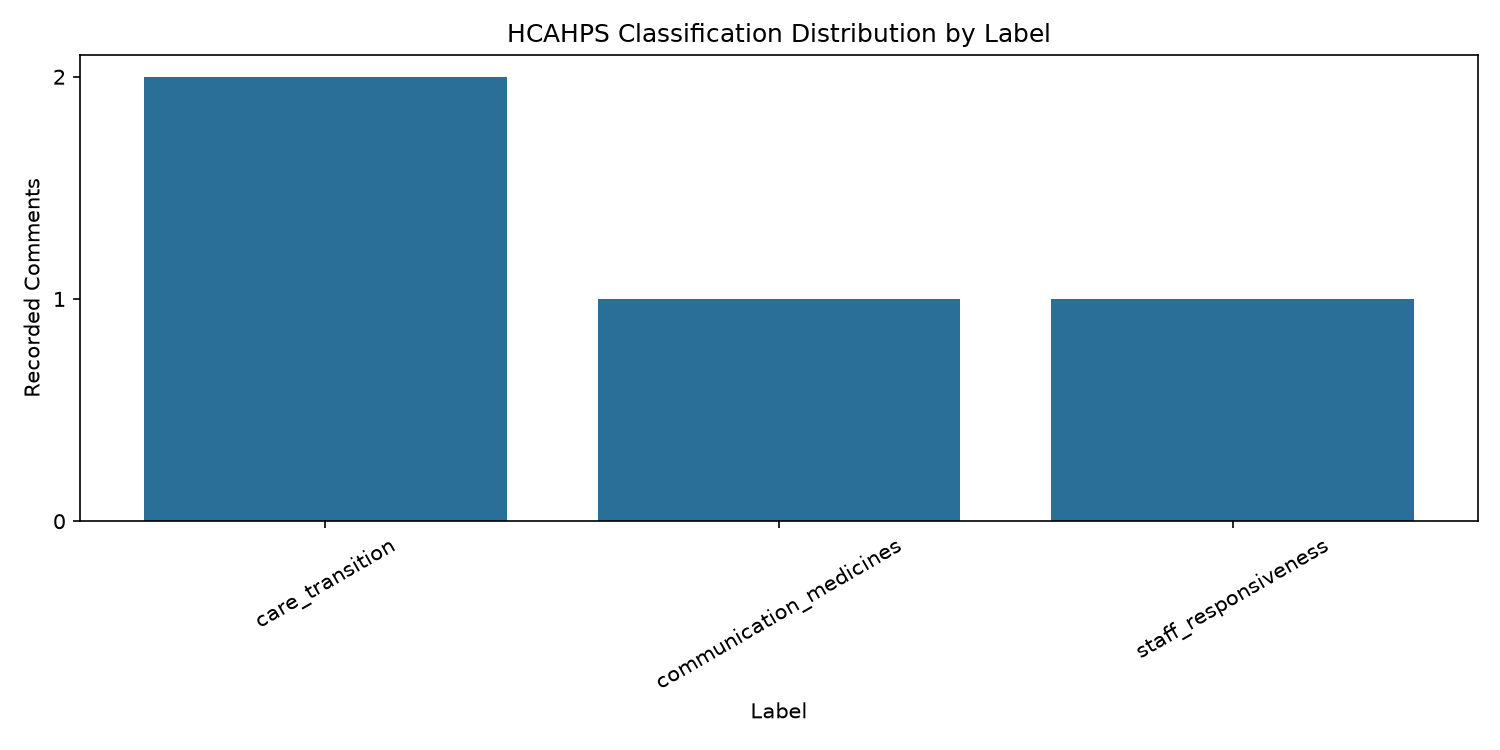

In [11]:
user_prompt4 = """
{"id": 12, "input": "The discharge plan assumed I could climb stairs, even though I told them I live alone on the third floor."}

Provide a summary of the patient experience ledger.
Provide a confidence statistic regarding the summary.
Provide a plot visualizing the patient experience.
"""


print(f"\n\n===================== Prompt {count}: user_prompt4 =====================")
print(f"\nUser request: {user_prompt4}")
print("\n")
response = run_agent(user_prompt4, system_prompt, max_iterations=10)


# Part 4: Find One failure and explain it.

### Failure Case

Below, I have pasted an example failure case. This occurred approximately 50% of the time when I ran `user_prompt3`. The issue I want to highlight is that, even though the prompt stated:

```text
{'id': 19, 'input': 'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.',}
give me the percentage of high confidence label predictions
```

the model chooses to call the `run_guarded_summary_statistic` tool first before recording the label classification of the instance of id: 19 and the patient response with the `record_classification` tool. So in turn 1 the model outputs a summary confidence statistic that is actually missing the example it is about to record in turn 2. It then records the classification which adds an additional label. Additionally the final answer itself does not answer the request of the intial prompt, which was to give the percentage of high confidence label predictions. By the time it gets to the turn 3, where the model creates a final output after two turns of sequential tool calls, the model drops that portion of the request.  If you look at the output of `user_prompt4` (above) we see the model is able to record a classification, output a summary, output a confidence percentage and plot. The final respnse of `user_prompt4` was able give a good final output that answers all of the user request across more turns. 

In [12]:
'''
===================== Prompt 3: user_prompt3 =====================

User request:  {'id': 19, 'input': 'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.',}
 give me the percentage of high confidence label predictions


                ========= Turn 1 =========                 

====== 🛠️ Tool Call : Call ID - call_11KkrGGCsk8PSFuHRVHhSPxR ======

Tool call: run_guarded_summary_statistic
---------------------------------
{
  "operation": "percentage_for_confidence",
  "category": "high"
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool": "run_guarded_summary_statistic",
  "output": {
    "category": "high",
    "matches": 2,
    "percentage": 100.0
  }
}


                ========= Turn 2 =========                 

====== 🛠️ Tool Call : Call ID - call_sAsmFonyyUHzFBgdOAG9AGoY ======

Tool call: record_classification
---------------------------------
{
  "comment_id": 19,
  "label": "communication_medicines",
  "confidence": "high",
  "rationale": "The comment mentions that 'nobody explained the new shot,' which directly relates to staff explaining a new medication and its effects during the hospital stay."
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool": "record_classification",
  "output": {
    "recorded_comment_id": 19,
    "recorded_total": 3,
    "label": "communication_medicines",
    "label_count": 1
  }
}


                ========= Turn 3 =========                 

Final answer: The comment was classified under **communication_medicines** with high confidence because it mentioned that "nobody explained the new shot," which relates to explaining medications during the hospital stay.

The updated tally now includes 3 total classifications, with 1 under communication_medicines.

'''

'\n===================== Prompt 3: user_prompt3 =====================\n\nUser request:  {\'id\': 19, \'input\': \'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.\',}\n give me the percentage of high confidence label predictions\n\n\n                ========= Turn 1 =========                 \n\n====== 🛠️ Tool Call : Call ID - call_11KkrGGCsk8PSFuHRVHhSPxR ======\n\nTool call: run_guarded_summary_statistic\n---------------------------------\n{\n  "operation": "percentage_for_confidence",\n  "category": "high"\n}\n\nTool response:\n---------------------------------\n{\n  "ok": true,\n  "tool": "run_guarded_summary_statistic",\n  "output": {\n    "category": "high",\n    "matches": 2,\n    "percentage": 100.0\n  }\n}\n\n\n                ========= Turn 2 =========                 \n\n====== 🛠️ Tool Call : Call ID - call_sAsmFonyyUHzFBgdOAG9AGoY ======\n\nTool call: record_classification\n---------------------------------\n{\n  "comment_id": 19,\n  "label"

### Schema in question

``` python
guarded_summary_statistic_tool = {
    "type": "function",
    "name": "run_guarded_summary_statistic",
    "description": (
        "Run one allowlisted, read-only HCAHPS ledger calculation. Use this for a "
        "single total, most-common label, or percentage. It cannot execute arbitrary code."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "operation": {
                "type": "string",
                "enum": [
                    "total_classifications",
                    "percentage_for_label",
                    "percentage_for_confidence",
                    "most_common_label",
                ],
            },
            "category": {
                "type": "string",
                "enum": LABELS + CONFIDENCE_LEVELS + ["not_applicable"],
            },
        },
        "required": ["operation", "category"],
        "additionalProperties": False,
    },
}

```

### Intervention 1: Change the Tool Description

My proposed solution was to make the tool description in the schema of `guarded_summary_statistic_tool`  more precise because the tool call is difficult to understand. Its purpose could also be confused with that of the `get_summary()` function.

In [13]:
guarded_summary_statistic_tool = {
    "type": "function",
    "name": "run_guarded_summary_statistic",
    "description": (
        "Run exactly one allowlisted, read-only calculation on the current HCAHPS "
        "classification ledger. Use it only after recording every patient comment "
        "included in the user's request with record_classification. It can return "
        "the total number of recorded classifications, the most common HCAHPS label, "
        "the percentage for one HCAHPS label, or the percentage for one confidence "
        "level. It cannot classify comments, modify the ledger, or execute arbitrary code."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "operation": {
                "type": "string",
                "enum": [
                    "total_classifications",
                    "percentage_for_label",
                    "percentage_for_confidence",
                    "most_common_label",
                ],
            },
            "category": {
                "type": "string",
                "enum": LABELS + CONFIDENCE_LEVELS + ["not_applicable"],
            },
        },
        "required": ["operation", "category"],
        "additionalProperties": False,
    },
}


In [14]:
# Define the failure prompt for testing high confidence label predictions

failure_prompt = " {'id': 19, 'input': 'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.',}\n give me the percentage of high confidence label predictions"


# Add the updated schema to the tools
TOOLS = [
    record_classification_tool,
    get_summary_tool,
    plot_distribution_tool,
    guarded_summary_statistic_tool,
]

# Clear the Ledger
LEDGER = {} # Clear the ledger after running the example above

# loop 
for attempt in range(1, 5):
    print(f"\n{'=' * 40} Fix Check #{attempt} {'=' * 40}")
    print(f"User request: {failure_prompt}\n")

    result = run_agent(failure_prompt,system_prompt,max_iterations=4,tools=TOOLS)



======================================== Fix Check #1 ========================================
User request:  {'id': 19, 'input': 'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.',}
 give me the percentage of high confidence label predictions

                ========= Turn 1 =========                 

====== 🛠️ Tool Call : Call ID - call_f8kH6u7QUbnuq4DLvz5mmC1Q ======

Tool call: record_classification
---------------------------------
{
  "comment_id": 19,
  "label": "communication_medicines",
  "confidence": "high",
  "rationale": "The comment mentions that nobody explained the new shot, which directly relates to whether staff explained a new medication and its side effects during the hospital stay."
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool": "record_classification",
  "output": {
    "recorded_comment_id": 19,
    "recorded_total": 1,
    "label": "communication_medicines",
    "label_count": 1
  }
}


         

### Note

After Intervention 1, three of the four initial runs followed the intended sequence: `record_classification` on turn 1, `run_guarded_summary_statistic` on turn 2, and a final summary on turn 3. In the remaining run, the model incorrectly calculated the statistic before recording the new classification.**

I reran the notebook three additional times but could not reproduce the ordering error. Nevertheless, the initial inconsistent result showed that changing the tool description alone did not reliably enforce the required sequence. This motivated Intervention 2, which added explicit tool-ordering instructions to the system prompt.

### Intervention 2: Change System Prompt 

Updating the tool description itself did not work every time. It worked 75% of the time where the model chose to attempt to classify the patient response sample and then call the summary statistic. In Fix Check  # 4 we can see that in that run the model decided to do the summary statistic on confidence 1st before then trying to classify this.  I want to point out that in all of the fix attempts there is a failure to actually record the classification as seen by the Tool response `"ok" : false`. This is expected when trying to record the same ID in the ledger. However that is not the issue we are looking at. I am trying to look at the order of tool calling. 

I am going to try updating the actual system prompt tool description and see if that helps. 
Current tool use system prompt description in `v1.txt`
"
```text
## Tool-use instructions

Determine the user's intent before selecting a tool.

available tools:
* `record_classification` 
* `get_summary` 
* `run_guarded_summary_statistic`
* `plot_distribution`

Use tool results when answering. Do not invent classifications, counts,
percentages, or plot locations.

```

I will change it to the text below in `v2.txt`

```text
## Tool-use instructions

Determine the user's intent before selecting a tool.

- If the user provides a patient-experience comment to classify, select one
  primary HCAHPS label and call `record_classification` exactly once.
- Use `get_summary` only when the user asks for a complete breakdown of all
    labels or all confidence levels.
- Use `run_guarded_summary_statistic` for one focused statistic: the total
    number of classifications, the most common label, the percentage for one
    HCAHPS label, or the percentage for one confidence level. For example, to
    answer "What percentage were high confidence?", call it with
    `operation="percentage_for_confidence"` and `category="high"`. Ensure this
    is completed after  `record_classification` if both are required to answer
    the user.
- If the user asks for a chart or visualization of recorded classifications,
  call `plot_distribution`.
- If the request is unrelated to HCAHPS classification or recorded results,
  ask a brief clarifying question.

Use tool results when answering. Do not invent classifications, counts,
percentages, or plot locations.
```

In [15]:
# Load the descriptive prompt for the HCAHPS classifier. This is prompt `v2.txt`
descriptive_prompt = load(name="hcahps-classifier", version="v2")

# Clear the Ledger
LEDGER = {} # Clear the ledger after running the example above

# loop 
for attempt in range(1, 5):
    print(f"\n{'=' * 40} Fix Check #{attempt} {'=' * 40}")
    print(f"User request: {failure_prompt}\n")

    result = run_agent(failure_prompt,descriptive_prompt,max_iterations=4,tools=TOOLS)


======================================== Fix Check #1 ========================================
User request:  {'id': 19, 'input': 'Nurse was nice i guess but nobody expained the new shot and my arm hurt after it.',}
 give me the percentage of high confidence label predictions

                ========= Turn 1 =========                 

====== 🛠️ Tool Call : Call ID - call_l7adBQXLMO2Ue1tOe9DWtslq ======

Tool call: record_classification
---------------------------------
{
  "comment_id": 19,
  "label": "communication_medicines",
  "confidence": "high",
  "rationale": "The comment mentions that 'nobody explained the new shot,' which directly relates to staff explaining a new medication during the hospital stay. This aligns with the communication_medicines category."
}

Tool response:
---------------------------------
{
  "ok": true,
  "tool": "record_classification",
  "output": {
    "recorded_comment_id": 19,
    "recorded_total": 1,
    "label": "communication_medicines",
    "labe

### Summary of Failure Case Correction

Changing only the tool description did not fix the issue with the order of tool calls. I was hoping that the text in the description would provide some logic about when the tool should be executed, not just what it did. The majority of runs on the failed prompt correctly fired record_classification and then run_guarded_summary_statistic as appropriate, but the fourth call did not. This shows that updating the tool description alone did not work.

I turned to changing the system prompt itself. I think this is an issue with the teh model reasoning about when to fire tools. I could have added a chain-of-thought portion to the system prompt, but I decided to update the tool-call portion of the v1 system prompt with text that prompts the LLM to consider when to call the tool and determine the user's intention before calling tools.

My intervention of changing both the tool description first and then the system prompt worked. I am unsure whether changing the system prompt first would have solved the problem, but for the sake of this project, which focuses on tool calling, and in practice, I imagine it was most appropriate to try editing the tool description before moving to the system prompt.


**Links**
- [System Prompt Version 1](prompts/hcahps-classifier/v1.txt)
- [System Prompt Version 2](prompts/hcahps-classifier/v2.txt)
- [System Prompt Change Log](prompts/hcahps-classifier/prompt-changelogs/v2.md)

## Part 5: Submit
Open a pull request with your schema design write-up, a link to your notebook, and a link to an issue documenting the failure and recovery. Describe your code-runner's allowlist, time limit, and blocked operations. Rubric: schemas (20), loop including a two-step sequence (25), guarded code-runner (20), failure with recovery (20), PR hygiene (15).